In [3]:
import stim
import math

In [ ]:
def Lattice_Surgery(distance: int, target_state_init: str, control_state_init: str) -> stim.Circuit:
    '''
    Generates Lattice Surgery by implementing a large lattice with 3 seperate states encoded and perfoming a CX

    Arguments:
                -> target_state_init: In which basis should the target lattice be initlized?
                -> control_state_init: In which basis should the control lattice be initilized?

    Returns:
                -> Fully implemented CX-Gate in stim.Circuit format
    '''

    #------------Preliminary-Setup------------

    #Checking Distance
    if distance <= 2:
        raise ValueError("Length must be a minimum of 3")
    
    #Checking Odd Distance
    if distance % 2 == 0:
        raise ValueError("Distance must be odd")
    
    #Implementing Coordinate for Qubits
    qubit_coords_ancilla: dict[complex, str] = {}
    stab_to_data_ancilla: dict[list[complex], str] = {}
    qubit_coords_target: dict[complex, str] = {}
    stab_to_data_target: dict[list[complex], str] = {}
    qubit_coords_control: dict[complex, str] = {}
    stab_to_data_control: dict[list[complex], str] = {}
    qubit_coords_surgery: dict[complex, str] = {}

    #----------Coordinate-Setup----------------

    #Data/Stab Coords
    start_with_x = True

    for real in range(distance * 2):
        stab_counter = 0  # Reset for each row

        for imag in range(distance * 2):

        # Create Data Coords
            if real % 2 != 0 and imag % 2 != 0:
                coord_ancilla = complex(real, imag)
                coord_target = complex(real + (distance * 2), imag)
                coord_control = complex(real, imag + (distance * 2))
                qubit_coords_ancilla[coord_ancilla] = "DATA"
                qubit_coords_target[coord_target] = "DATA"
                qubit_coords_control[coord_control] = "DATA"

        # Check Stabilizer Positions
            elif real % 2 == 0 and imag % 2 == 0:
                # Exclude Boundary
                if real != 0 and imag != 0:
                    coord_ancilla = complex(real, imag)
                    coord_target = complex(real + (distance * 2), imag)
                    coord_control = complex(real, imag + (distance * 2))

                    # Decide which stabilizer to use
                    if start_with_x:
                        # Even positions are X, odd are Z
                        if stab_counter % 2 == 0:
                            qubit_coords_ancilla[coord_ancilla] = "X-STAB"
                            qubit_coords_target[coord_target] = "Z-STAB"
                            qubit_coords_control[coord_control] = "Z-STAB"
                        else:
                            qubit_coords_ancilla[coord_ancilla] = "Z-STAB"
                            qubit_coords_target[coord_target] = "X-STAB"
                            qubit_coords_control[coord_control] = "X-STAB"
                    else:
                        # Even positions are Z, odd are X
                        if stab_counter % 2 == 0:
                            qubit_coords_ancilla[coord_ancilla] = "Z-STAB"
                            qubit_coords_target[coord_target] = "X-STAB"
                            qubit_coords_control[coord_control] = "X-STAB"
                        else:
                            qubit_coords_ancilla[coord_ancilla] = "X-STAB"
                            qubit_coords_target[coord_target] = "Z-STAB"
                            qubit_coords_control[coord_control] = "Z-STAB"

                    stab_counter += 1

        # After finishing a row, flip the starting stabilizer for the next row
        if real % 2 == 0 and real != 0:
            start_with_x = not start_with_x

    #Create Boundary Stab Coords & Surgery Stabilizer Coords (Only get activated in splitting/merging process)
    max_coord = 2 * distance

    """
    In theroy one needs to change the application of the boundary stab. 
    for even and odd distances but odd distances are the only practical code 
    length so we check for odd distance right at the beginning(makes no sene to 
    include them here for the boundary stab)
    """

    # Z-boundary stabilizers
    for y in range(2, max_coord, 4):
        coord_ancilla = complex(0, y)
        coord_target = complex(distance * 2, y + 2)
        coord_control = complex(0, y + 2 + (distance * 2))
        coord_lattice = complex(y + 2, max_coord)
        qubit_coords_ancilla[coord_ancilla] = "Z-STAB-BOUND-L-A"
        qubit_coords_target[coord_target] = "Z-STAB-BOUND-L-T"
        qubit_coords_control[coord_control] = "Z-STAB-BOUND-L-C"
        qubit_coords_surgery[coord_lattice] = "Z-STAB-SURGERY-M"

    for y in range(4, max_coord, 4):
        coord_ancilla = complex(max_coord, y)
        coord_target = complex(max_coord + (distance * 2), y - 2)
        coord_control = complex(max_coord, y - 2 + (distance * 2)) 
        qubit_coords_ancilla[coord_ancilla] = "Z-STAB-BOUND-R-A"
        qubit_coords_target[coord_target] = "Z-STAB-BOUND-R-T"
        qubit_coords_control[coord_control] = "Z-STAB-BOUND-R-C"

    # X-boundary stabilizers
    for y in range(4, max_coord, 4):
        coord_ancilla = complex(y, 0)
        coord_target = complex(y - 2 + (distance * 2), 0)
        coord_control = complex(y - 2, distance * 2)
        coord_lattice = complex(max_coord, y-2)
        qubit_coords_ancilla[coord_ancilla] = "X-STAB-BOUND-A-A"
        qubit_coords_target[coord_target] = "X-STAB-BOUND-A-T"
        qubit_coords_control[coord_control] = "X-STAB-BOUND-A-C"
        qubit_coords_surgery[coord_lattice] = "X-STAB-SURGERY-M"

    for y in range(2, max_coord, 4):
        coord_ancilla = complex(y, max_coord)
        coord_target = complex(y + 2 + (distance * 2), max_coord)
        coord_control = complex(y + 2, max_coord + (distance * 2))
        qubit_coords_ancilla[coord_ancilla] = "X-STAB-BOUND-B-A"
        qubit_coords_target[coord_target] = "X-STAB-BOUND-B-T"
        qubit_coords_control[coord_control] = "X-STAB-BOUND-B-C"

    #Adding X Surgery Stabilizer Between Ancilla & Target
    qubit_coords_surgery[complex(max_coord, max_coord)] = "X-STAB-SURGERY-B"

    #Adding Z Surgery Stabilizer Between Ancilla & Control
    qubit_coords_surgery[complex(0, max_coord)] = "Z-STAB-SURGERY-L"

    """
    Implementing CX-Gates used for the creation of the stabilizer measurements
    """

    #------CX-GATES-ANCILLA------
    for coords,string in qubit_coords_ancilla.items():
        #Already in Correct Orientation for Measurement of CX
        if string == "X-STAB":
            new_cord1 = (coords.real + 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real - 1) + (coords.imag - 1) * 1j
            new_cord3 = (coords.real + 1) + (coords.imag + 1) * 1j
            new_cord4 = (coords.real - 1) + (coords.imag + 1) * 1j
            stab_to_data_ancilla[new_cord1, coords] = "1-CX"
            stab_to_data_ancilla[new_cord2, coords] = "2-CX"
            stab_to_data_ancilla[new_cord3, coords] = "3-CX"
            stab_to_data_ancilla[new_cord4, coords] = "4-CX"

        elif string == "Z-STAB":
            new_cord1 = (coords.real + 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real + 1) + (coords.imag + 1) * 1j
            new_cord3 = (coords.real - 1) + (coords.imag - 1) * 1j
            new_cord4 = (coords.real - 1) + (coords.imag + 1) * 1j
            stab_to_data_ancilla[coords, new_cord1] = "1-CX"
            stab_to_data_ancilla[coords, new_cord2] = "2-CX"
            stab_to_data_ancilla[coords, new_cord3] = "3-CX"
            stab_to_data_ancilla[coords, new_cord4] = "4-CX"

        elif string == "Z-STAB-BOUND-L-A":
            new_cord1 = (coords.real + 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real + 1 ) + (coords.imag + 1) * 1j
            stab_to_data_ancilla[coords, new_cord1] = "1-CX"
            stab_to_data_ancilla[coords, new_cord2] = "2-CX"

        elif string == "Z-STAB-BOUND-R-A":
            new_cord1 = (coords.real - 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real - 1 ) + (coords.imag + 1) * 1j
            stab_to_data_ancilla[coords, new_cord1] = "3-CX"
            stab_to_data_ancilla[coords, new_cord2] = "4-CX"
        
        elif string == "X-STAB-BOUND-A-A":
            new_cord1 = (coords.real - 1) + (coords.imag + 1) * 1j
            new_cord2 = (coords.real + 1 ) + (coords.imag + 1) * 1j
            stab_to_data_ancilla[new_cord1, coords] = "4-CX"
            stab_to_data_ancilla[new_cord2, coords] = "3-CX"

        elif string == "X-STAB-BOUND-B-A":
            new_cord1 = (coords.real - 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real + 1 ) + (coords.imag - 1) * 1j
            stab_to_data_ancilla[new_cord1, coords] = "2-CX"
            stab_to_data_ancilla[new_cord2, coords] = "1-CX"

    #------CX-GATES-TARGET------
    for coords,string in qubit_coords_target.items():
        #Already in Correct Orientation for Measurement of CX
        if string == "X-STAB":
            new_cord1 = (coords.real + 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real - 1) + (coords.imag - 1) * 1j
            new_cord3 = (coords.real + 1) + (coords.imag + 1) * 1j
            new_cord4 = (coords.real - 1) + (coords.imag + 1) * 1j
            stab_to_data_target[new_cord1, coords] = "1-CX"
            stab_to_data_target[new_cord2, coords] = "2-CX"
            stab_to_data_target[new_cord3, coords] = "3-CX"
            stab_to_data_target[new_cord4, coords] = "4-CX"

        elif string == "Z-STAB":
            new_cord1 = (coords.real + 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real + 1) + (coords.imag + 1) * 1j
            new_cord3 = (coords.real - 1) + (coords.imag - 1) * 1j
            new_cord4 = (coords.real - 1) + (coords.imag + 1) * 1j
            stab_to_data_target[coords, new_cord1] = "1-CX"
            stab_to_data_target[coords, new_cord2] = "2-CX"
            stab_to_data_target[coords, new_cord3] = "3-CX"
            stab_to_data_target[coords, new_cord4] = "4-CX"

        elif string == "Z-STAB-BOUND-L-T":
            new_cord1 = (coords.real + 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real + 1 ) + (coords.imag + 1) * 1j
            stab_to_data_target[coords, new_cord1] = "5-CX"
            stab_to_data_target[coords, new_cord2] = "6-CX"

        elif string == "Z-STAB-BOUND-R-T":
            new_cord1 = (coords.real - 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real - 1 ) + (coords.imag + 1) * 1j
            stab_to_data_target[coords, new_cord1] = "5-CX"
            stab_to_data_target[coords, new_cord2] = "6-CX"
        
        elif string == "X-STAB-BOUND-A-T":
            new_cord1 = (coords.real - 1) + (coords.imag + 1) * 1j
            new_cord2 = (coords.real + 1 ) + (coords.imag + 1) * 1j
            stab_to_data_target[new_cord1, coords] = "5-CX"
            stab_to_data_target[new_cord2, coords] = "6-CX"

        elif string == "X-STAB-BOUND-B-T":
            new_cord1 = (coords.real - 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real + 1 ) + (coords.imag - 1) * 1j
            stab_to_data_target[new_cord1, coords] = "5-CX"
            stab_to_data_target[new_cord2, coords] = "6-CX"

    #------CX-GATES-CONTROL------
    for coords,string in qubit_coords_control.items():
        #Already in Correct Orientation for Measurement of CX
        if string == "X-STAB":
            new_cord1 = (coords.real + 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real - 1) + (coords.imag - 1) * 1j
            new_cord3 = (coords.real + 1) + (coords.imag + 1) * 1j
            new_cord4 = (coords.real - 1) + (coords.imag + 1) * 1j
            stab_to_data_control[new_cord1, coords] = "1-CX"
            stab_to_data_control[new_cord2, coords] = "2-CX"
            stab_to_data_control[new_cord3, coords] = "3-CX"
            stab_to_data_control[new_cord4, coords] = "4-CX"

        elif string == "Z-STAB":
            new_cord1 = (coords.real + 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real + 1) + (coords.imag + 1) * 1j
            new_cord3 = (coords.real - 1) + (coords.imag - 1) * 1j
            new_cord4 = (coords.real - 1) + (coords.imag + 1) * 1j
            stab_to_data_control[coords, new_cord1] = "1-CX"
            stab_to_data_control[coords, new_cord2] = "2-CX"
            stab_to_data_control[coords, new_cord3] = "3-CX"
            stab_to_data_control[coords, new_cord4] = "4-CX"

        elif string == "Z-STAB-BOUND-L-C":
            new_cord1 = (coords.real + 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real + 1 ) + (coords.imag + 1) * 1j
            stab_to_data_control[coords, new_cord1] = "5-CX"
            stab_to_data_control[coords, new_cord2] = "6-CX"

        elif string == "Z-STAB-BOUND-R-C":
            new_cord1 = (coords.real - 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real - 1 ) + (coords.imag + 1) * 1j
            stab_to_data_control[coords, new_cord1] = "5-CX"
            stab_to_data_control[coords, new_cord2] = "6-CX"
        
        elif string == "X-STAB-BOUND-A-C":
            new_cord1 = (coords.real - 1) + (coords.imag + 1) * 1j
            new_cord2 = (coords.real + 1 ) + (coords.imag + 1) * 1j
            stab_to_data_control[new_cord1, coords] = "5-CX"
            stab_to_data_control[new_cord2, coords] = "6-CX"

        elif string == "X-STAB-BOUND-B-C":
            new_cord1 = (coords.real - 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real + 1 ) + (coords.imag - 1) * 1j
            stab_to_data_control[new_cord1, coords] = "5-CX"
            stab_to_data_control[new_cord2, coords] = "6-CX"
    
    
    #Merging all Coordinates for Indexing
    merged = qubit_coords_ancilla | qubit_coords_control | qubit_coords_target | qubit_coords_surgery

    #Indexing Qubits
    q2i: dict[complex, int] = {q: i for i, q in enumerate(
    sorted(merged, key=lambda v: (v.real, v.imag))
    )}

    #Reverse Indexing
    i2q: dict[int, complex] = {i: q for q, i in q2i.items()}

    #Indexing Z and X Stabilizers
    x_stab_index_ancilla = [q2i[q] for q, qtype in qubit_coords_ancilla.items() if qtype in {"X-STAB","X-STAB-BOUND-A-A", "X-STAB-BOUND-B-A"}]
    z_stab_index_ancilla = [q2i[q] for q, qtype in qubit_coords_ancilla.items() if qtype in {"Z-STAB","Z-STAB-BOUND-L-A", "Z-STAB-BOUND-R-A"}]
    x_stab_boundary_b_index_ancilla = [q2i[q] for q, qtype in qubit_coords_ancilla.items() if qtype == "X-STAB-BOUND-B-A"]
    x_stab_index_target = [q2i[q] for q, qtype in qubit_coords_target.items() if qtype in {"X-STAB","X-STAB-BOUND-A-T", "X-STAB-BOUND-B-T"}]
    z_stab_index_target = [q2i[q] for q, qtype in qubit_coords_target.items() if qtype in {"Z-STAB","Z-STAB-BOUND-L-T", "Z-STAB-BOUND-R-T"}]
    x_stab_index_control = [q2i[q] for q, qtype in qubit_coords_control.items() if qtype in {"X-STAB","X-STAB-BOUND-A-C", "X-STAB-BOUND-B-C"}]
    z_stab_index_control = [q2i[q] for q, qtype in qubit_coords_control.items() if qtype in {"Z-STAB","Z-STAB-BOUND-L-C", "Z-STAB-BOUND-R-C"}]

    #Indexing Data-Qubits
    data_ancilla = [q2i[q] for q, qtype in qubit_coords_ancilla.items() if qtype == "DATA"]
    data_target = [q2i[q] for q, qtype in qubit_coords_target.items() if qtype == "DATA"]
    data_control = [q2i[q] for q, qtype in qubit_coords_control.items() if qtype == "DATA"]
    
    #Building Circuit
    inital_circuit = stim.Circuit()
    merge_init_circuit = stim.Circuit()
    merge_round_circuit = stim.Circuit()

    #-----BUILDING-INITILIZATION-CIRCUIT----

    #Appending Coords
    for q, i in q2i.items():
        inital_circuit.append("QUBIT_COORDS", [i], [q.real, q.imag])

    """
    Looking at every state preperation seperatly seems to be inefficient
    ->  If not all Operators only once used one gets an incorrect formatting in the 
        timeslice view because of the Operations being in different timeslices in each TICK!
    """

    #Inilizing Ancilla in Plus (Reset) and Control/ Target in desired State
    if control_state_init == "Z0" and target_state_init == "Z0":
        inital_circuit.append("RX", data_ancilla)
        inital_circuit.append("R", data_control + data_target)
        inital_circuit.append("Z", data_ancilla)

    elif control_state_init == "Z0" and target_state_init == "Z1":
        inital_circuit.append("RX", data_ancilla)
        inital_circuit.append("R", data_control + data_target)
        inital_circuit.append("X", data_target)
        inital_circuit.append("Z", data_ancilla)

    elif control_state_init == "Z0" and target_state_init == "X+":
        inital_circuit.append("RX", data_ancilla + data_target)
        inital_circuit.append("R", data_control)
        inital_circuit.append("Z", data_ancilla + data_target)

    elif control_state_init == "Z0" and target_state_init == "X-":
        inital_circuit.append("RX", data_ancilla + data_target)
        inital_circuit.append("R", data_control)
        inital_circuit.append("Z", data_ancilla)

    elif control_state_init == "Z1" and target_state_init == "Z0":
        inital_circuit.append("RX", data_ancilla)
        inital_circuit.append("R", data_control + data_target)
        inital_circuit.append("X", data_control)
        inital_circuit.append("Z", data_ancilla)

    elif control_state_init == "Z1" and target_state_init == "Z1":
        inital_circuit.append("RX", data_ancilla)
        inital_circuit.append("R", data_control + data_target)
        inital_circuit.append("X", data_control + data_target)
        inital_circuit.append("Z", data_ancilla)

    elif control_state_init == "Z1" and target_state_init == "X+":
        inital_circuit.append("RX", data_ancilla + data_target)
        inital_circuit.append("R", data_control)
        inital_circuit.append("X", data_control)
        inital_circuit.append("Z", data_ancilla + data_target)

    elif control_state_init == "Z1" and target_state_init == "X-":
        inital_circuit.append("RX", data_ancilla + data_target)
        inital_circuit.append("R", data_control)
        inital_circuit.append("X", data_control)
        inital_circuit.append("Z", data_ancilla)

    elif control_state_init == "X+" and target_state_init == "Z0":
        inital_circuit.append("RX", data_ancilla + data_control)
        inital_circuit.append("R", data_target)
        inital_circuit.append("Z", data_ancilla + data_control)

    elif control_state_init == "X+" and target_state_init == "Z1":
        inital_circuit.append("RX", data_ancilla + data_control)
        inital_circuit.append("R", data_target)
        inital_circuit.append("X", data_target)
        inital_circuit.append("Z", data_ancilla + data_control)

    elif control_state_init == "X+" and target_state_init == "X+":
        inital_circuit.append("RX", data_ancilla + data_control + data_target)
        inital_circuit.append("Z", data_ancilla + data_control + data_target)

    elif control_state_init == "X+" and target_state_init == "X-":
        inital_circuit.append("RX", data_ancilla + data_control + data_target)
        inital_circuit.append("Z", data_ancilla + data_target)

    elif control_state_init == "X-" and target_state_init == "Z0":
        inital_circuit.append("RX", data_ancilla + data_control)
        inital_circuit.append("R", data_target)
        inital_circuit.append("Z", data_ancilla)

    elif control_state_init == "X-" and target_state_init == "Z1":
        inital_circuit.append("RX", data_ancilla + data_control)
        inital_circuit.append("R", data_target)
        inital_circuit.append("X", data_target)
        inital_circuit.append("Z", data_ancilla)

    elif control_state_init == "X-" and target_state_init == "X+":
        inital_circuit.append("RX", data_ancilla + data_control + data_target)
        inital_circuit.append("Z", data_ancilla + data_control)

    elif control_state_init == "X-" and target_state_init == "X-":
        inital_circuit.append("RX", data_ancilla + data_control + data_target)
        inital_circuit.append("Z", data_ancilla + data_control + data_target)

    else:
        raise ValueError("Not a valid Basis for initlization in the Control Lattice")

    inital_circuit.append("TICK")

    #Adding h gate for X stabilizers -> Filtering out double coords
    combined_x_stab : list = []
    for coords in (x_stab_index_ancilla + x_stab_index_control + x_stab_index_target):
        if coords not in combined_x_stab:
            combined_x_stab.append(coords)

    inital_circuit.append("H", combined_x_stab)
    inital_circuit.append("TICK")

    #2) CX Operations

    for coord_pairs, order in (stab_to_data_ancilla | stab_to_data_control | stab_to_data_target).items():
   
        #Parallel Implementation of CX
        if order == "1-CX":
            index_pairs = []
            index_pairs.append(q2i[coord_pairs[1]])
            index_pairs.append(q2i[coord_pairs[0]])
            inital_circuit.append("CX", index_pairs)

    inital_circuit.append("TICK")
            
    for coord_pairs, order in (stab_to_data_ancilla | stab_to_data_control | stab_to_data_target).items():
   
        #Parallel Implementation of CX
        if order == "2-CX":
            index_pairs = []
            index_pairs.append(q2i[coord_pairs[1]])
            index_pairs.append(q2i[coord_pairs[0]])
            inital_circuit.append("CX", index_pairs)

    inital_circuit.append("TICK")

    for coord_pairs, order in (stab_to_data_ancilla | stab_to_data_control | stab_to_data_target).items():
   
        #Parallel Implementation of CX
        if order == "3-CX":
            index_pairs = []
            index_pairs.append(q2i[coord_pairs[1]])
            index_pairs.append(q2i[coord_pairs[0]])
            inital_circuit.append("CX", index_pairs)
    
    inital_circuit.append("TICK")
        
    for coord_pairs, order in (stab_to_data_ancilla | stab_to_data_control | stab_to_data_target).items():
   
        #Parallel Implementation of CX
        if order == "4-CX":
            index_pairs = []
            index_pairs.append(q2i[coord_pairs[1]])
            index_pairs.append(q2i[coord_pairs[0]])
            inital_circuit.append("CX", index_pairs)

    #Retreive Boundary + Normal Stabilizers Ancilla (Basis change and Measurement -> Measurement only in the x Basis UPDATE!!!!!):
    inital_circuit.append("TICK")
    inital_circuit.append("H", x_stab_index_ancilla)
    inital_circuit.append("TICK")
    inital_circuit.append("MR", x_stab_index_ancilla + z_stab_index_ancilla)
    inital_circuit.append("TICK")
    inital_circuit.append("H", x_stab_boundary_b_index_ancilla)
    inital_circuit.append("TICK")

    #-----Implementing Detectors for Ancilla (+ State -> X Basis is deterministic)-----

    #Determining Position in the measurement Run of only the Ancilla
    pos_to_index_ancilla_x : list = []
    pos_to_index_ancilla_z : list = []

    for pos, index in enumerate(x_stab_index_ancilla + z_stab_index_ancilla):
        if index in x_stab_index_ancilla:
            pos_to_index_ancilla_x.append([pos, index])

        elif index in z_stab_index_ancilla:
            pos_to_index_ancilla_z.append([pos, index])

    #Adding the needed Detectors
    for index_pos in pos_to_index_ancilla_x:
        current_tar = index_pos[0] - len(x_stab_index_ancilla + z_stab_index_ancilla)
        q_index = index_pos[1]
        inital_circuit.append("DETECTOR", [stim.target_rec(current_tar)], (i2q[q_index].real, i2q[q_index].imag, 0))


    #Continue CX-Implementation for Target and Control (As Ancilla already has a full run)
    for coord_pairs, order in (stab_to_data_ancilla | stab_to_data_control | stab_to_data_target).items():
   
        #Parallel Implementation of CX
        if order == "5-CX":
            index_pairs = []
            index_pairs.append(q2i[coord_pairs[1]])
            index_pairs.append(q2i[coord_pairs[0]])
            inital_circuit.append("CX", index_pairs)

    inital_circuit.append("TICK")

    for coord_pairs, order in (stab_to_data_ancilla | stab_to_data_control | stab_to_data_target).items():
   
        #Parallel Implementation of CX
        if order == "6-CX":
            index_pairs = []
            index_pairs.append(q2i[coord_pairs[1]])
            index_pairs.append(q2i[coord_pairs[0]])
            inital_circuit.append("CX", index_pairs)

    #All Stabilizers from the Target and Control Lattice
    control_target_stabs = x_stab_index_control + x_stab_index_target + z_stab_index_control + z_stab_index_target

    #Retreive Boundary + Normal Stabilizers from Target and Control (Basis Change + Measurement):
    inital_circuit.append("TICK")
    inital_circuit.append("H", x_stab_index_control +  x_stab_index_target)
    inital_circuit.append("TICK")
    inital_circuit.append("MR", control_target_stabs)

    #4) DETECTORS -> Only record Targets from deterministic results. i.e stabilizers from the current basis!
    
    #Determining Postion in the measurement Run of Target & Control
    pos_to_index_control_x : list = []
    pos_to_index_control_z : list = []
    pos_to_index_target_x : list = []
    pos_to_index_target_z : list = []

    for pos, index in enumerate(control_target_stabs):
        if index in x_stab_index_control:
            pos_to_index_control_x.append([pos, index])

        elif index in z_stab_index_control:
            pos_to_index_control_z.append([pos, index])

        elif index in x_stab_index_target:
            pos_to_index_target_x.append([pos, index])

        elif index in z_stab_index_target:
            pos_to_index_target_z.append([pos, index])
    
    #-----Implementing Detectors for Control-----

    #Z-Basis (0/1 - state)
    if control_state_init in {"Z0", "Z1"}:

        for index_pos in pos_to_index_control_z:
            current_tar = index_pos[0] - len(control_target_stabs)
            q_index = index_pos[1]
            inital_circuit.append("DETECTOR", [stim.target_rec(current_tar)], (i2q[q_index].real, i2q[q_index].imag, 0))
    
    #X-Basis (+/- - state)
    elif control_state_init in {"X-", "X+"}:

        for index_pos in pos_to_index_control_x:
            current_tar = index_pos[0] - len(control_target_stabs)
            q_index = index_pos[1]
            inital_circuit.append("DETECTOR", [stim.target_rec(current_tar)], (i2q[q_index].real, i2q[q_index].imag, 0))
        
    else:
        raise ValueError("Not a valid Basis for initlization in the Control Lattice")

    #-----Implementing Detectors for Target-----
    
    #Z-Basis (0/1 - state)
    if target_state_init in {"Z0", "Z1"}:
  
        for index_pos in pos_to_index_target_z:
            current_tar = index_pos[0] - len(control_target_stabs)
            q_index = index_pos[1]
            inital_circuit.append("DETECTOR", [stim.target_rec(current_tar)], (i2q[q_index].real, i2q[q_index].imag, 0))
    
    #X-Basis (+/- - state)
    elif target_state_init in {"X-", "X+"}:

        for index_pos in pos_to_index_target_x:
            current_tar = index_pos[0] - len(control_target_stabs)
            q_index = index_pos[1]
            inital_circuit.append("DETECTOR", [stim.target_rec(current_tar)], (i2q[q_index].real, i2q[q_index].imag, 0))
        
    else:
        raise ValueError("Not a valid Basis for initlization in the Target Lattice")

    #-----Merging-Control-----

    #Indexing of the additional Stabilizers included in the merging/splitting process
    z_stab_index_surgery = [q2i[q] for q, qtype in qubit_coords_surgery.items() if qtype == "Z-STAB-SURGERY-M"]
    z_stab_boundary_l_surgery = [q2i[q] for q, qtype in qubit_coords_surgery.items() if qtype == "Z-STAB-SURGERY-L"]
    stab_to_data_ancilla_control: dict[list[complex], str] = {}

    """
    We now redefine the CX implementation which now does Control + Ancilla as one lattice!
    """

    #------CX-GATES-ANCILLA-&-CONTROL------
    for coords,string in (qubit_coords_ancilla | qubit_coords_surgery | qubit_coords_control).items():
        #Already in Correct Orientation for Measurement of CX
        if string in {"X-STAB", "X-STAB-BOUND-A-C"}:
            new_cord1 = (coords.real + 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real - 1) + (coords.imag - 1) * 1j
            new_cord3 = (coords.real + 1) + (coords.imag + 1) * 1j
            new_cord4 = (coords.real - 1) + (coords.imag + 1) * 1j
            stab_to_data_ancilla_control[new_cord1, coords] = "1-CX"
            stab_to_data_ancilla_control[new_cord2, coords] = "2-CX"
            stab_to_data_ancilla_control[new_cord3, coords] = "3-CX"
            stab_to_data_ancilla_control[new_cord4, coords] = "4-CX"

        elif string in {"Z-STAB", "Z-STAB-SURGERY-M"}:
            new_cord1 = (coords.real + 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real + 1) + (coords.imag + 1) * 1j
            new_cord3 = (coords.real - 1) + (coords.imag - 1) * 1j
            new_cord4 = (coords.real - 1) + (coords.imag + 1) * 1j
            stab_to_data_ancilla_control[coords, new_cord1] = "1-CX"
            stab_to_data_ancilla_control[coords, new_cord2] = "2-CX"
            stab_to_data_ancilla_control[coords, new_cord3] = "3-CX"
            stab_to_data_ancilla_control[coords, new_cord4] = "4-CX"

        elif string in {"Z-STAB-BOUND-L-A", "Z-STAB-BOUND-L-C", "Z-STAB-SURGERY-L"}:
            new_cord1 = (coords.real + 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real + 1 ) + (coords.imag + 1) * 1j
            stab_to_data_ancilla_control[coords, new_cord1] = "1-CX"
            stab_to_data_ancilla_control[coords, new_cord2] = "2-CX"

        elif string in {"Z-STAB-BOUND-R-A", "Z-STAB-BOUND-R-C"}:
            new_cord1 = (coords.real - 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real - 1 ) + (coords.imag + 1) * 1j
            stab_to_data_ancilla_control[coords, new_cord1] = "3-CX"
            stab_to_data_ancilla_control[coords, new_cord2] = "4-CX"
        
        elif string == "X-STAB-BOUND-A-A":
            new_cord1 = (coords.real - 1) + (coords.imag + 1) * 1j
            new_cord2 = (coords.real + 1 ) + (coords.imag + 1) * 1j
            stab_to_data_ancilla_control[new_cord1, coords] = "4-CX"
            stab_to_data_ancilla_control[new_cord2, coords] = "3-CX"

        elif string == "X-STAB-BOUND-B-C":
            new_cord1 = (coords.real - 1) + (coords.imag - 1) * 1j
            new_cord2 = (coords.real + 1 ) + (coords.imag - 1) * 1j
            stab_to_data_ancilla_control[new_cord1, coords] = "2-CX"
            stab_to_data_ancilla_control[new_cord2, coords] = "1-CX"

    #Adding h gate for X stabilizers -> Filtering out double coords
    combined_x_stab : list = []
    for coords in (x_stab_index_ancilla + x_stab_index_control + x_stab_index_target):
        if coords not in combined_x_stab:
            combined_x_stab.append(coords)

    merge_init_circuit.append("TICK")
    merge_init_circuit.append("H", combined_x_stab)
    merge_init_circuit.append("TICK")

    #2) CX Operations

    for coord_pairs, order in (stab_to_data_ancilla_control |stab_to_data_target).items():
   
        #Parallel Implementation of CX
        if order == "1-CX":
            index_pairs = []
            index_pairs.append(q2i[coord_pairs[1]])
            index_pairs.append(q2i[coord_pairs[0]])
            merge_init_circuit.append("CX", index_pairs)

    merge_init_circuit.append("TICK")
            
    for coord_pairs, order in (stab_to_data_ancilla_control |stab_to_data_target).items():
   
        #Parallel Implementation of CX
        if order == "2-CX":
            index_pairs = []
            index_pairs.append(q2i[coord_pairs[1]])
            index_pairs.append(q2i[coord_pairs[0]])
            merge_init_circuit.append("CX", index_pairs)

    merge_init_circuit.append("TICK")

    for coord_pairs, order in (stab_to_data_ancilla_control |stab_to_data_target).items():
   
        #Parallel Implementation of CX
        if order == "3-CX":
            index_pairs = []
            index_pairs.append(q2i[coord_pairs[1]])
            index_pairs.append(q2i[coord_pairs[0]])
            merge_init_circuit.append("CX", index_pairs)
    
    merge_init_circuit.append("TICK")
        
    for coord_pairs, order in (stab_to_data_ancilla_control |stab_to_data_target).items():
   
        #Parallel Implementation of CX
        if order == "4-CX":
            index_pairs = []
            index_pairs.append(q2i[coord_pairs[1]])
            index_pairs.append(q2i[coord_pairs[0]])
            merge_init_circuit.append("CX", index_pairs)

    #Adding h gate for X stabilizers -> Filtering out double coords in big lattice
    combined_x_stab_ac : list = []
    for coords in (x_stab_index_ancilla + x_stab_index_control):
        if coords not in combined_x_stab_ac:
            combined_x_stab_ac.append(coords)

    combined_z_stab_ac : list = []
    for coords in (z_stab_index_ancilla + z_stab_index_control + z_stab_boundary_l_surgery + z_stab_index_surgery):
        if coords not in combined_z_stab_ac:
            combined_z_stab_ac.append(coords)

    #Retreive Boundary + Normal Stabilizers Ancilla (Basis change and Measurement):
    merge_init_circuit.append("TICK")
    merge_init_circuit.append("H", combined_x_stab_ac)
    merge_init_circuit.append("TICK")
    merge_init_circuit.append("MR", combined_z_stab_ac + combined_x_stab_ac)
    merge_init_circuit.append("TICK")

    #Adding Detectors -> Firstly Stabilizers which measurement is already known i.e. outside of merging region

    #Determining Position in the measurement Run of only the Ancilla (Shared Stabilizers excluded)
    pos_to_index_ancilla_x_ac : list = []
    pos_to_index_ancilla_z_ac : list = []

    for pos, index in enumerate(combined_z_stab_ac + combined_x_stab_ac):
        if index in x_stab_index_ancilla:
            if index not in x_stab_boundary_b_index_ancilla:
                pos_to_index_ancilla_x_ac.append([pos, index])

        elif index in z_stab_index_ancilla:
            pos_to_index_ancilla_z_ac.append([pos, index])

    #Adding the needed Detectors
    for index_pos_ac in pos_to_index_ancilla_x_ac:
        current_tar = index_pos_ac[0] - len(combined_z_stab_ac + combined_x_stab_ac)
        q_index = index_pos_ac[1]
        for index_pos in pos_to_index_ancilla_x:
            if q_index == index_pos[1]:
                previous_target = index_pos[0] - len(combined_z_stab_ac + combined_x_stab_ac) - len(control_target_stabs) - len(x_stab_index_ancilla + z_stab_index_ancilla)
                merge_init_circuit.append("DETECTOR", [stim.target_rec(current_tar), stim.target_rec(previous_target)], (i2q[q_index].real, i2q[q_index].imag, 1))

    #Determining Position in the measurement Run of only the Control (Shared Stabilizers excluded)
    pos_to_index_control_x_ac : list = []
    pos_to_index_control_z_ac : list = []

    for pos, index in enumerate(combined_z_stab_ac + combined_x_stab_ac):
        if index in x_stab_index_control:
            #Exclude Shared Ancillas i.e. below stabilizers from Ancilla
            if index not in x_stab_boundary_b_index_ancilla:
                pos_to_index_control_x_ac.append([pos, index])

        elif index in z_stab_index_control:
            pos_to_index_control_z_ac.append([pos, index])

    #Adding the needed Detectors dependent of logical state of the lattice

    #Z-Basis (0/1 - state)
    if control_state_init in {"Z0", "Z1"}:

        for index_pos_ac in pos_to_index_control_z_ac:
            current_tar = index_pos_ac[0] - len(combined_z_stab_ac + combined_x_stab_ac)
            q_index = index_pos_ac[1]
            for index_pos in pos_to_index_control_z:
                if q_index == index_pos[1]:
                    previous_target = index_pos[0] - len(combined_z_stab_ac + combined_x_stab_ac) - len(control_target_stabs)
                    merge_init_circuit.append("DETECTOR", [stim.target_rec(current_tar), stim.target_rec(previous_target)], (i2q[q_index].real, i2q[q_index].imag, 1))

    #X-Basis (+/- - state)
    elif control_state_init in {"X-", "X+"}:

        for index_pos_ac in pos_to_index_control_x_ac:
            current_tar = index_pos_ac[0] - len(combined_z_stab_ac + combined_x_stab_ac)
            q_index = index_pos_ac[1]
            for index_pos in pos_to_index_control_x:
                if q_index == index_pos[1]:
                    previous_target = index_pos[0] - len(combined_z_stab_ac + combined_x_stab_ac) - len(control_target_stabs)
                    merge_init_circuit.append("DETECTOR", [stim.target_rec(current_tar), stim.target_rec(previous_target)], (i2q[q_index].real, i2q[q_index].imag, 1))
        
    else:
        raise ValueError("Not a valid Basis for initlization in the Control Lattice")
    
    """
    We now initlize the stabilizers newly introduce through the merging; one has to distinguish two types
    1) Boundary stabilizers -> Newly formed weight 4 x stabilizers take measurement record of both old boundary weight 2 stabilizers of control and ancilla
    2) No record history -> Newly formed weight 4 z stabilizers have no old record history and therefore have an non deterministic outcome!
    """
    
    #Adding shared Stabilizers
    pos_to_index_shared_x_stabs : list = []

    for pos, index in enumerate(combined_z_stab_ac + combined_x_stab_ac):
        if index in x_stab_index_control:
            #Include Shared Ancillas i.e. below stabilizers from Ancilla
            if index in x_stab_boundary_b_index_ancilla:
                pos_to_index_shared_x_stabs.append([pos, index])

    #Adding the needed Detectors
    for index_pos_ac in pos_to_index_shared_x_stabs:
        current_tar = index_pos_ac[0] - len(combined_z_stab_ac + combined_x_stab_ac)
        q_index = index_pos_ac[1]
        for index_pos_a in pos_to_index_ancilla_x:
            if q_index == index_pos_a[1]:
                previous_target_ancilla = index_pos_a[0] - len(combined_z_stab_ac + combined_x_stab_ac) - len(control_target_stabs) - len(x_stab_index_ancilla + z_stab_index_ancilla)
                for index_pos_c in pos_to_index_control_x:
                    if q_index == index_pos_c[1]:
                        previous_target_control = index_pos_c[0] - len(combined_z_stab_ac + combined_x_stab_ac) - len(control_target_stabs) 
                        merge_init_circuit.append("DETECTOR", [stim.target_rec(current_tar), stim.target_rec(previous_target_ancilla), stim.target_rec(previous_target_control)], (i2q[q_index].real, i2q[q_index].imag, 1))

    #Continue CX-Implementation for Target (As AC-Lattice already has a full run)
    for coord_pairs, order in (stab_to_data_target).items():
   
        #Parallel Implementation of CX
        if order == "5-CX":
            index_pairs = []
            index_pairs.append(q2i[coord_pairs[1]])
            index_pairs.append(q2i[coord_pairs[0]])
            merge_init_circuit.append("CX", index_pairs)

    merge_init_circuit.append("TICK")

    for coord_pairs, order in (stab_to_data_target).items():
   
        #Parallel Implementation of CX
        if order == "6-CX":
            index_pairs = []
            index_pairs.append(q2i[coord_pairs[1]])
            index_pairs.append(q2i[coord_pairs[0]])
            merge_init_circuit.append("CX", index_pairs)

    #All Stabilizers from the Target and Control Lattice
    control_target_stabs = x_stab_index_control + x_stab_index_target + z_stab_index_control + z_stab_index_target

    #Retreive Boundary + Normal Stabilizers from Target and Control (Basis Change + Measurement):
    merge_init_circuit.append("TICK")
    merge_init_circuit.append("H", x_stab_index_target)
    merge_init_circuit.append("TICK")
    merge_init_circuit.append("MR", x_stab_index_target + z_stab_index_target)

    #Determining Position in the measurement Run of only the Target (Excluded from merge -> Normal stabilizer measurement)
    pos_to_index_target_x_ac : list = []
    pos_to_index_target_z_ac : list = []

    for pos, index in enumerate(x_stab_index_target + z_stab_index_target):
        if index in x_stab_index_target:
            pos_to_index_target_x_ac.append([pos, index])

        elif index in z_stab_index_target:
            pos_to_index_target_z_ac.append([pos, index])

    #Adding the needed Detectors dependent of logical state of the lattice

    #Z-Basis (0/1 - state)
    if target_state_init in {"Z0", "Z1"}:

        for index_pos_ac in pos_to_index_target_z_ac:
            current_tar = index_pos_ac[0] - len(x_stab_index_target + z_stab_index_target)
            q_index = index_pos_ac[1]
            for index_pos in pos_to_index_target_z:
                if q_index == index_pos[1]:
                    previous_target = index_pos[0] - len(x_stab_index_target + z_stab_index_target) - len(combined_z_stab_ac + combined_x_stab_ac) - len(control_target_stabs)
                    merge_init_circuit.append("DETECTOR", [stim.target_rec(current_tar), stim.target_rec(previous_target)], (i2q[q_index].real, i2q[q_index].imag, 1))

    #X-Basis (+/- - state)
    elif target_state_init in {"X-", "X+"}:

        for index_pos_ac in pos_to_index_target_x_ac:
            current_tar = index_pos_ac[0] - len(x_stab_index_target + z_stab_index_target)
            q_index = index_pos_ac[1]
            for index_pos in pos_to_index_target_x:
                if q_index == index_pos[1]:
                    previous_target = index_pos[0] - len(x_stab_index_target + z_stab_index_target) - len(combined_z_stab_ac + combined_x_stab_ac) - len(control_target_stabs)
                    merge_init_circuit.append("DETECTOR", [stim.target_rec(current_tar), stim.target_rec(previous_target)], (i2q[q_index].real, i2q[q_index].imag, 1))
        
    else:
        raise ValueError("Not a valid Basis for initlization in the Control Lattice")

    #----Merging-Repeat-Circuit---
    #Adding repeat circuit with all stabilizers defined

    merge_round_circuit.append("TICK")
    merge_round_circuit.append("H", combined_x_stab)
    merge_round_circuit.append("TICK")

    #2) CX Operations

    for coord_pairs, order in (stab_to_data_ancilla_control |stab_to_data_target).items():
   
        #Parallel Implementation of CX
        if order == "1-CX":
            index_pairs = []
            index_pairs.append(q2i[coord_pairs[1]])
            index_pairs.append(q2i[coord_pairs[0]])
            merge_round_circuit.append("CX", index_pairs)

    merge_round_circuit.append("TICK")
            
    for coord_pairs, order in (stab_to_data_ancilla_control |stab_to_data_target).items():
   
        #Parallel Implementation of CX
        if order == "2-CX":
            index_pairs = []
            index_pairs.append(q2i[coord_pairs[1]])
            index_pairs.append(q2i[coord_pairs[0]])
            merge_round_circuit.append("CX", index_pairs)

    merge_round_circuit.append("TICK")

    for coord_pairs, order in (stab_to_data_ancilla_control |stab_to_data_target).items():
   
        #Parallel Implementation of CX
        if order == "3-CX":
            index_pairs = []
            index_pairs.append(q2i[coord_pairs[1]])
            index_pairs.append(q2i[coord_pairs[0]])
            merge_round_circuit.append("CX", index_pairs)
    
    merge_round_circuit.append("TICK")
        
    for coord_pairs, order in (stab_to_data_ancilla_control |stab_to_data_target).items():
   
        #Parallel Implementation of CX
        if order == "4-CX":
            index_pairs = []
            index_pairs.append(q2i[coord_pairs[1]])
            index_pairs.append(q2i[coord_pairs[0]])
            merge_round_circuit.append("CX", index_pairs)

    #Retreive Boundary + Normal Stabilizers Ancilla (Basis change and Measurement):
    merge_round_circuit.append("TICK")
    merge_round_circuit.append("H", combined_x_stab_ac)
    merge_round_circuit.append("TICK")
    merge_round_circuit.append("MR", combined_z_stab_ac + combined_x_stab_ac)
    merge_round_circuit.append("TICK")

    #Adding Detectors -> Firstly Stabilizers which measurement is already known i.e. outside of merging region

    #Adding the needed Detectors for Ancilla
    for index_pos_ac in pos_to_index_ancilla_x_ac:
        current_tar = index_pos_ac[0] - len(combined_z_stab_ac + combined_x_stab_ac)
        previous_target = index_pos_ac[0] - 2 * len(combined_z_stab_ac + combined_x_stab_ac) - len(x_stab_index_target + z_stab_index_target)
        q_index = index_pos_ac[1]
        merge_round_circuit.append("DETECTOR", [stim.target_rec(current_tar), stim.target_rec(previous_target)], (i2q[q_index].real, i2q[q_index].imag, 2))

    #Adding the needed Detectors dependent of logical state of the lattice (Control)

    #Z-Basis (0/1 - state)
    if control_state_init in {"Z0", "Z1"}:

        for index_pos_ac in pos_to_index_control_z_ac:
            current_tar = index_pos_ac[0] - len(combined_z_stab_ac + combined_x_stab_ac)
            previous_target = index_pos_ac[0] - 2 * len(combined_z_stab_ac + combined_x_stab_ac) - len(x_stab_index_target + z_stab_index_target)
            q_index = index_pos_ac[1]
            merge_round_circuit.append("DETECTOR", [stim.target_rec(current_tar), stim.target_rec(previous_target)], (i2q[q_index].real, i2q[q_index].imag, 2))

    #X-Basis (+/- - state)
    elif control_state_init in {"X-", "X+"}:

        for index_pos_ac in pos_to_index_control_x_ac:
            current_tar = index_pos_ac[0] - len(combined_z_stab_ac + combined_x_stab_ac)
            previous_target = index_pos_ac[0] - 2 * len(combined_z_stab_ac + combined_x_stab_ac) - len(x_stab_index_target + z_stab_index_target)
            q_index = index_pos_ac[1]
            merge_round_circuit.append("DETECTOR", [stim.target_rec(current_tar), stim.target_rec(previous_target)], (i2q[q_index].real, i2q[q_index].imag, 2))
        
    else:
        raise ValueError("Not a valid Basis for initlization in the Control Lattice")
    
    #Adding the Ancialla Control shared Detectors
    for index_pos_ac in pos_to_index_shared_x_stabs:
        current_tar = index_pos_ac[0] - len(combined_z_stab_ac + combined_x_stab_ac)
        previous_target = index_pos_ac[0] - 2 * len(combined_z_stab_ac + combined_x_stab_ac) - len(x_stab_index_target + z_stab_index_target)
        q_index = index_pos_ac[1]
        merge_round_circuit.append("DETECTOR", [stim.target_rec(current_tar), stim.target_rec(previous_target)], (i2q[q_index].real, i2q[q_index].imag, 2))
                        
    #Adding newly generated Stabilizers
    pos_to_index_new_z_stabs : list = []

    for pos, index in enumerate(combined_z_stab_ac + combined_x_stab_ac):
        if index in (z_stab_index_surgery + z_stab_boundary_l_surgery):
            pos_to_index_new_z_stabs.append([pos, index])

    #Adding the needed Detectors (Newly Z generated Stabs)
    for index_pos_ac in pos_to_index_new_z_stabs:
        current_tar = index_pos_ac[0] - len(combined_z_stab_ac + combined_x_stab_ac)
        previous_target = index_pos_ac[0] - 2 * len(combined_z_stab_ac + combined_x_stab_ac) - len(x_stab_index_target + z_stab_index_target)
        q_index = index_pos_ac[1]
        merge_round_circuit.append("DETECTOR", [stim.target_rec(current_tar), stim.target_rec(previous_target)], (i2q[q_index].real, i2q[q_index].imag, 2))

    #Continue CX-Implementation for Target (As AC-Lattice already has a full run)
    for coord_pairs, order in (stab_to_data_target).items():
   
        #Parallel Implementation of CX
        if order == "5-CX":
            index_pairs = []
            index_pairs.append(q2i[coord_pairs[1]])
            index_pairs.append(q2i[coord_pairs[0]])
            merge_round_circuit.append("CX", index_pairs)

    merge_round_circuit.append("TICK")

    for coord_pairs, order in (stab_to_data_target).items():
   
        #Parallel Implementation of CX
        if order == "6-CX":
            index_pairs = []
            index_pairs.append(q2i[coord_pairs[1]])
            index_pairs.append(q2i[coord_pairs[0]])
            merge_round_circuit.append("CX", index_pairs)

    #All Stabilizers from the Target and Control Lattice
    control_target_stabs = x_stab_index_control + x_stab_index_target + z_stab_index_control + z_stab_index_target

    #Retreive Boundary + Normal Stabilizers from Target and Control (Basis Change + Measurement):
    merge_round_circuit.append("TICK")
    merge_round_circuit.append("H", x_stab_index_target)
    merge_round_circuit.append("TICK")
    merge_round_circuit.append("MR", x_stab_index_target + z_stab_index_target)

    #Adding the needed Detectors dependent of logical state of the lattice

    #Z-Basis (0/1 - state)
    if target_state_init in {"Z0", "Z1"}:

        for index_pos_ac in pos_to_index_target_z_ac:
            current_tar = index_pos_ac[0] - len(x_stab_index_target + z_stab_index_target)
            previous_target = index_pos_ac[0] - len(combined_z_stab_ac + combined_x_stab_ac) - 2 * len(x_stab_index_target + z_stab_index_target)
            q_index = index_pos_ac[1]
            merge_round_circuit.append("DETECTOR", [stim.target_rec(current_tar), stim.target_rec(previous_target)], (i2q[q_index].real, i2q[q_index].imag, 2))

    #X-Basis (+/- - state)
    elif target_state_init in {"X-", "X+"}:

        for index_pos_ac in pos_to_index_target_x_ac:
            current_tar = index_pos_ac[0] - len(x_stab_index_target + z_stab_index_target)
            previous_target = index_pos_ac[0] - len(combined_z_stab_ac + combined_x_stab_ac) - 2 * len(x_stab_index_target + z_stab_index_target)
            q_index = index_pos_ac[1]
            merge_round_circuit.append("DETECTOR", [stim.target_rec(current_tar), stim.target_rec(previous_target)], (i2q[q_index].real, i2q[q_index].imag, 2))
    
    else:
        raise ValueError("Not a valid Basis for initlization in the Control Lattice")
    
    merge_round_circuit.append("SHIFT_COORDS", arg=(0,0,1))
    
    #Implementing Final Measurement Round (All Data qubits)
    merge_final_circuit = stim.Circuit()

    #Detectors for Target

    # -> Defining Data to measurement indexing
    Index_to_rec_data : dict[int, int] = {q: i for i, q in enumerate(reversed(data_target))}
    Index_to_rec_target: dict[int, int] = {q: i for i, q in enumerate(reversed(x_stab_index_target + z_stab_index_target))}

    #Z-Basis (0/1 - state)
    if target_state_init in {"Z0", "Z1"}:

        merge_final_circuit.append("TICK")
        merge_final_circuit.append("M", data_target)

        for q, qtype in qubit_coords_target.items():

            if qtype == "Z-STAB":
                #Needed Data Qubits
                upper_left = (q.real - 1) + (q.imag - 1) * 1j
                upper_right = (q.real + 1) + (q.imag - 1) * 1j
                lower_left = (q.real - 1) + (q.imag + 1) * 1j
                lower_right = (q.real + 1) + (q.imag + 1) * 1j

                #Finding the Correct Data Index
                index_upper_left = q2i[upper_left]
                index_upper_right = q2i[upper_right]
                index_lower_left = q2i[lower_left]
                index_lower_right = q2i[lower_right]

                #Defining the current record targets
                current_record = [-Index_to_rec_data[index_upper_left] - 1, -Index_to_rec_data[index_upper_right] - 1,
                                -Index_to_rec_data[index_lower_left] - 1, -Index_to_rec_data[index_lower_right] - 1]

                #Defining the last record targets (Normal Detectors from last round)
                stab_index = q2i[q]
                last_record = [- Index_to_rec_target[stab_index] - 1 - len(data_target)]

                #Combining the record targets
                final_record = current_record + last_record
                
                #Appending Detector
                merge_final_circuit.append("DETECTOR", [stim.target_rec(i) for i in final_record], arg = (q.real, q.imag, 2))

            elif qtype == "Z-STAB-BOUND-L-T":
                #Needed Data Qubits
                upper_right = (q.real + 1) + (q.imag - 1) * 1j
                lower_right = (q.real + 1) + (q.imag + 1) * 1j

                #Finding the Correct Data Index
                index_upper_right = q2i[upper_right]
                index_lower_right = q2i[lower_right]

                #Defining the current record targets
                current_record = [-Index_to_rec_data[index_upper_right] - 1, -Index_to_rec_data[index_lower_right] - 1]

                #Defining the last record targets (Normal Detectors from last round)
                stab_index = q2i[q]
                last_record = [- Index_to_rec_target[stab_index] - 1 - len(data_target)]

                #Combining the record targets
                final_record = current_record + last_record
                
                #Appending Detector
                merge_final_circuit.append("DETECTOR", [stim.target_rec(i) for i in final_record], arg = (q.real, q.imag, 2))

            elif qtype == "Z-STAB-BOUND-R-T":
                #Needed Data Qubits
                upper_left = (q.real - 1) + (q.imag - 1) * 1j
                lower_left = (q.real - 1) + (q.imag + 1) * 1j

                #Finding the Correct Data Index
                index_upper_left = q2i[upper_left]
                index_lower_left = q2i[lower_left]

                #Defining the current record targets
                current_record = [-Index_to_rec_data[index_upper_left] - 1, -Index_to_rec_data[index_lower_left] - 1]

                #Defining the last record targets (Normal Detectors from last round)
                stab_index = q2i[q]
                last_record = [- Index_to_rec_target[stab_index] - 1 - len(data_target)]

                #Combining the record targets
                final_record = current_record + last_record
                
                #Appending Detector
                merge_final_circuit.append("DETECTOR", [stim.target_rec(i) for i in final_record], arg = (q.real, q.imag, 2))

    #X-Basis (+/- - state)
    elif target_state_init in {"X-", "X+"}:

        #Basis Change
        merge_final_circuit.append("TICK")
        merge_final_circuit.append("H", data_target)
        merge_final_circuit.append("TICK")
        merge_final_circuit.append("M", data_target)

        for q, qtype in qubit_coords_target.items():

            if qtype == "X-STAB":
                #Needed Data Qubits
                upper_left = (q.real - 1) + (q.imag - 1) * 1j
                upper_right = (q.real + 1) + (q.imag - 1) * 1j
                lower_left = (q.real - 1) + (q.imag + 1) * 1j
                lower_right = (q.real + 1) + (q.imag + 1) * 1j

                #Finding the Correct Data Index
                index_upper_left = q2i[upper_left]
                index_upper_right = q2i[upper_right]
                index_lower_left = q2i[lower_left]
                index_lower_right = q2i[lower_right]

                #Defining the current record targets
                current_record = [-Index_to_rec_data[index_upper_left] - 1, -Index_to_rec_data[index_upper_right] - 1,
                                -Index_to_rec_data[index_lower_left] - 1, -Index_to_rec_data[index_lower_right] - 1]

                #Defining the last record targets (Normal Detectors from last round)
                stab_index = q2i[q]
                last_record = [- Index_to_rec_target[stab_index] - 1 - len(data_target)]

                #Combining the record targets
                final_record = current_record + last_record
                
                #Appending Detector
                merge_final_circuit.append("DETECTOR", [stim.target_rec(i) for i in final_record], arg = (q.real, q.imag, 2))

            elif qtype == "X-STAB-BOUND-A-T":
                #Needed Data Qubits
                lower_left = (q.real - 1) + (q.imag + 1) * 1j
                lower_right = (q.real + 1) + (q.imag + 1) * 1j

                #Finding the Correct Data Index
                index_lower_left = q2i[lower_left]
                index_lower_right = q2i[lower_right]

                #Defining the current record targets
                current_record = [-Index_to_rec_data[index_lower_left] - 1, -Index_to_rec_data[index_lower_right] - 1]

                #Defining the last record targets (Normal Detectors from last round)
                stab_index = q2i[q]
                last_record = [- Index_to_rec_target[stab_index] - 1 - len(data_target)]

                #Combining the record targets
                final_record = current_record + last_record
                
                #Appending Detector
                merge_final_circuit.append("DETECTOR", [stim.target_rec(i) for i in final_record], arg = (q.real, q.imag, 2))

            elif qtype == "X-STAB-BOUND-B-T":
                #Needed Data Qubits
                upper_left = (q.real - 1) + (q.imag - 1) * 1j
                upper_right = (q.real + 1) + (q.imag - 1) * 1j

                #Finding the Correct Data Index
                index_upper_left = q2i[upper_left]
                index_upper_right = q2i[upper_right]

                #Defining the current record targets
                current_record = [-Index_to_rec_data[index_upper_left] - 1, -Index_to_rec_data[index_upper_right] - 1]

                #Defining the last record targets (Normal Detectors from last round)
                stab_index = q2i[q]
                last_record = [- Index_to_rec_target[stab_index] - 1 - len(data_target)]

                #Combining the record targets
                final_record = current_record + last_record
                
                #Appending Detector
                merge_final_circuit.append("DETECTOR", [stim.target_rec(i) for i in final_record], arg = (q.real, q.imag, 2))

    #Detectors for Ancilla (Non Merged)

    #Detectors for Control (Non Merged)

    #Detectors for merged Section
        
    #Adding conditional Z gate on target, if X_L is uneven

    

    #-----Splitting-Control-----

    """
    -> Redefine Logical Operators
    -> After Split d rounds of Stabilizer Measurements for fault tolerance
    """

    #-----Merging-Target-----

    #Indexing of the additional Stabilizers included in the merging process
    x_stab_index_lattice = [q2i[q] for q, qtype in qubit_coords_surgery.items() if qtype == "X-STAB-SURGERY-M"]
    x_stab_boundary_b_lattice = [q2i[q] for q, qtype in qubit_coords_surgery.items() if qtype == "X-STAB-SURGERY-B"]

    """
    -> After merge logical Operators have to be redefined
    -> After Merge d rounds of Stabilizer Measurements for fault tolerance
    """

    #-----Splitting-Target-----

    """
    -> Redefine Logical Operators
    -> After Split d rounds of Stabilizer Measurements for fault tolerance
    """

    #-----Appending-all-Circuits------

    inital_circuit += merge_init_circuit
    inital_circuit += merge_round_circuit * (distance - 2)
    inital_circuit += merge_final_circuit


    #-----Retrieving-Final-Circuit------
    """
    We use inlined feedback to track the necessary flips after measurement outcomes clasically, instead of phsically flipping the qubits
    """

    #return_circuit = inital_circuit.with_inlined_feedback()

    return(inital_circuit)

In [68]:
Lattice_Surgery(3,1,control_state_init= "X+",target_state_init= "X-").detector_error_model()

stim.DetectorErrorModel('''
    detector(2, 2, 0) D0
    detector(4, 4, 0) D1
    detector(4, 0, 0) D2
    detector(2, 6, 0) D3
    detector(2, 10, 0) D4
    detector(4, 8, 0) D5
    detector(2, 6, 0) D6
    detector(4, 12, 0) D7
    detector(8, 4, 0) D8
    detector(10, 2, 0) D9
    detector(8, 0, 0) D10
    detector(10, 6, 0) D11
    detector(2, 2, 1) D12
    detector(4, 4, 1) D13
    detector(4, 0, 1) D14
    detector(2, 10, 1) D15
    detector(4, 8, 1) D16
    detector(4, 12, 1) D17
    detector(2, 6, 1) D18
    detector(8, 4, 1) D19
    detector(10, 2, 1) D20
    detector(8, 0, 1) D21
    detector(10, 6, 1) D22
    detector(2, 2, 2) D23
    detector(4, 4, 2) D24
    detector(4, 0, 2) D25
    detector(2, 10, 2) D26
    detector(4, 8, 2) D27
    detector(4, 12, 2) D28
    detector(2, 6, 2) D29
    detector(0, 6, 2) D30
    detector(4, 6, 2) D31
    detector(8, 4, 2) D32
    detector(10, 2, 2) D33
    detector(8, 0, 2) D34
    detector(10, 6, 2) D35
    shift_detectors(0, 0, 1) 0
   

In [ ]:
test_circuit = stim.Circuit("""
QUBIT_COORDS(0, 2) 0
QUBIT_COORDS(0.5, 0.5) 1
QUBIT_COORDS(0.5, 1.5) 2
QUBIT_COORDS(0.5, 2.5) 3
QUBIT_COORDS(1, 0) 4
QUBIT_COORDS(1, 1) 5
QUBIT_COORDS(1, 2) 6
QUBIT_COORDS(1.5, 0.5) 7
QUBIT_COORDS(1.5, 1.5) 8
QUBIT_COORDS(1.5, 2.5) 9
QUBIT_COORDS(2, 1) 10
QUBIT_COORDS(2, 2) 11
QUBIT_COORDS(2, 3) 12
QUBIT_COORDS(2.5, 0.5) 13
QUBIT_COORDS(2.5, 1.5) 14
QUBIT_COORDS(2.5, 2.5) 15
QUBIT_COORDS(3, 0) 16
QUBIT_COORDS(3, 1) 17
QUBIT_COORDS(3, 2) 18
QUBIT_COORDS(3.5, 0.5) 19
QUBIT_COORDS(3.5, 1.5) 20
QUBIT_COORDS(3.5, 2.5) 21
QUBIT_COORDS(4, 1) 22
QUBIT_COORDS(4, 2) 23
QUBIT_COORDS(4, 3) 24
QUBIT_COORDS(4.5, 0.5) 25
QUBIT_COORDS(4.5, 1.5) 26
QUBIT_COORDS(4.5, 2.5) 27
QUBIT_COORDS(5, 0) 28
QUBIT_COORDS(5, 1) 29
QUBIT_COORDS(5, 2) 30
QUBIT_COORDS(5.5, 0.5) 31
QUBIT_COORDS(5.5, 1.5) 32
QUBIT_COORDS(5.5, 2.5) 33
QUBIT_COORDS(6, 1) 34
QUBIT_COORDS(6, 2) 35
QUBIT_COORDS(6, 3) 36
QUBIT_COORDS(6.5, 0.5) 37
QUBIT_COORDS(6.5, 1.5) 38
QUBIT_COORDS(6.5, 2.5) 39
QUBIT_COORDS(7, 1) 40
#!pragma POLYGON(0,0,1,0.25) 7 13 14 8
#!pragma POLYGON(0,0,1,0.25) 2 8 9 3
#!pragma POLYGON(0,0,1,0.25) 7 1
#!pragma POLYGON(0,0,1,0.25) 15 9
#!pragma POLYGON(0,0,1,0.25) 31 37 38 32
#!pragma POLYGON(0,0,1,0.25) 26 32 33 27
#!pragma POLYGON(0,0,1,0.25) 31 25
#!pragma POLYGON(0,0,1,0.25) 39 33
#!pragma POLYGON(1,0,0,0.25) 1 7 8 2
#!pragma POLYGON(1,0,0,0.25) 8 14 15 9
#!pragma POLYGON(1,0,0,0.25) 2 3
#!pragma POLYGON(1,0,0,0.25) 13 14
#!pragma POLYGON(1,0,0,0.25) 25 31 32 26
#!pragma POLYGON(1,0,0,0.25) 32 38 39 33
#!pragma POLYGON(1,0,0,0.25) 26 27
#!pragma POLYGON(1,0,0,0.25) 37 38
TICK
R 1 2 3 7 8 9 13 14 15 25 26 27 31 32 33 37 38 39
#!pragma MARKZ(1) 25 26 27 13 14 15
TICK
R 6 10 4 12 30 34 28 36
RX 5 11 0 17 29 35 23 40
#!pragma MARKX(0) 1 7 13 25 31 37
TICK
CX 5 1 2 6 7 10 11 8 9 12 17 13 29 25 26 30 31 34 35 32 33 36 40 37
TICK
CX 8 6 13 10 5 2 11 9 15 12 17 14 32 30 37 34 29 26 35 33 39 36 40 38
TICK
CX 3 6 8 10 1 4 5 7 0 2 11 14 27 30 32 34 25 28 29 31 23 26 35 38
TICK
CX 5 8 9 6 14 10 11 15 0 3 7 4 29 32 33 30 38 34 35 39 23 27 31 28
TICK
M 6 10 4 12 30 34 28 36
MX 5 11 0 17 29 35 23 40
DETECTOR(1, 2, 0) rec[-16]
DETECTOR(2, 1, 0) rec[-15]
DETECTOR(1, 0, 0) rec[-14]
DETECTOR(2, 3, 0) rec[-13]
DETECTOR(5, 2, 0) rec[-12]
DETECTOR(6, 1, 0) rec[-11]
DETECTOR(5, 0, 0) rec[-10]
DETECTOR(6, 3, 0) rec[-9]
TICK
#!pragma POLYGON(0,0,1,0.25) 2 8 9 3
#!pragma POLYGON(0,0,1,0.25) 7 1
#!pragma POLYGON(0,0,1,0.25) 15 9
#!pragma POLYGON(0,0,1,0.25) 31 37 38 32
#!pragma POLYGON(0,0,1,0.25) 31 25
#!pragma POLYGON(0,0,1,0.25) 39 33
#!pragma POLYGON(0,0,1,0.25) 7 13 14 8
#!pragma POLYGON(0,0,1,0.25) 26 32 33 27
#!pragma POLYGON(1,0,0,0.25) 1 7 8 2
#!pragma POLYGON(1,0,0,0.25) 8 14 15 9
#!pragma POLYGON(1,0,0,0.25) 2 3
#!pragma POLYGON(1,0,0,0.25) 25 31 32 26
#!pragma POLYGON(1,0,0,0.25) 32 38 39 33
#!pragma POLYGON(1,0,0,0.25) 37 38
#!pragma POLYGON(1,0,0,0.25) 20
#!pragma POLYGON(1,0,0,0.25) 19
#!pragma POLYGON(1,0,0,0.25) 21
#!pragma POLYGON(1,0,0,0.25) 13 19 20 14
#!pragma POLYGON(1,0,0,0.25) 20 26 27 21
TICK
R 6 10 4 12 30 34 28 36 18 22 24 16
RX 5 11 0 17 29 35 23 40 19 20 21
#!pragma MARKX(0) 19
#!pragma MARKZ(1) 18 16 24 22
TICK
CX 5 1 2 6 7 10 11 8 9 12 17 13 29 25 26 30 31 34 35 32 33 36 40 37 14 18 19 22 23 20 21 24
TICK
CX 8 6 13 10 5 2 11 9 15 12 17 14 32 30 37 34 29 26 35 33 39 36 40 38 20 18 23 21 27 24 25 22
TICK
CX 3 6 8 10 1 4 5 7 0 2 11 14 27 30 32 34 25 28 29 31 23 26 35 38 15 18 20 22 17 19 13 16
TICK
CX 5 8 9 6 14 10 11 15 0 3 7 4 29 32 33 30 38 34 35 39 23 27 31 28 17 20 26 22 19 16 21 18
TICK
M 6 10 4 12 30 34 28 36 24 16 22 18
MX 5 11 0 17 29 35 23 40
#!pragma MARKZ(1) 24 16 22 18
DETECTOR(1, 2, 1) rec[-20] rec[-36]
DETECTOR(2, 1, 1) rec[-19] rec[-35]
DETECTOR(1, 0, 1) rec[-18] rec[-34]
DETECTOR(2, 3, 1) rec[-17] rec[-33]
DETECTOR(5, 2, 1) rec[-16] rec[-32]
DETECTOR(6, 1, 1) rec[-15] rec[-31]
DETECTOR(5, 0, 1) rec[-14] rec[-30]
DETECTOR(6, 3, 1) rec[-13] rec[-29]
DETECTOR(1, 1, 1) rec[-8] rec[-28]
DETECTOR(2, 2, 1) rec[-7] rec[-27]
DETECTOR(0, 2, 1) rec[-6] rec[-26]
DETECTOR(3, 1, 1) rec[-5] rec[-25]
DETECTOR(5, 1, 1) rec[-4] rec[-24]
DETECTOR(6, 2, 1) rec[-3] rec[-23]
DETECTOR(4, 2, 1) rec[-2] rec[-22]
DETECTOR(7, 1, 1) rec[-1] rec[-21]
OBSERVABLE_INCLUDE(0) rec[-9] rec[-10] rec[-11] rec[-12] rec[-17] rec[-18] rec[-19] rec[-20]
TICK
#!pragma POLYGON(0,0,1,0.25) 2 8 9 3
#!pragma POLYGON(0,0,1,0.25) 7 1
#!pragma POLYGON(0,0,1,0.25) 15 9
#!pragma POLYGON(0,0,1,0.25) 31 37 38 32
#!pragma POLYGON(0,0,1,0.25) 31 25
#!pragma POLYGON(0,0,1,0.25) 39 33
#!pragma POLYGON(0,0,1,0.25) 7 13 14 8
#!pragma POLYGON(0,0,1,0.25) 26 32 33 27
#!pragma POLYGON(0,0,1,0.25) 19 25 26 20
#!pragma POLYGON(0,0,1,0.25) 19 13
#!pragma POLYGON(0,0,1,0.25) 27 21
#!pragma POLYGON(0,0,1,0.25) 14 20 21 15
#!pragma POLYGON(1,0,0,0.25) 1 7 8 2
#!pragma POLYGON(1,0,0,0.25) 8 14 15 9
#!pragma POLYGON(1,0,0,0.25) 2 3
#!pragma POLYGON(1,0,0,0.25) 25 31 32 26
#!pragma POLYGON(1,0,0,0.25) 32 38 39 33
#!pragma POLYGON(1,0,0,0.25) 37 38
#!pragma POLYGON(1,0,0,0.25) 13 19 20 14
#!pragma POLYGON(1,0,0,0.25) 20 26 27 21
TICK
R 6 10 4 12 30 34 28 36 18 22 24 16
RX 5 11 0 17 29 35 23 40
TICK
CX 5 1 2 6 7 10 11 8 9 12 17 13 29 25 26 30 31 34 35 32 33 36 40 37 14 18 19 22 23 20 21 24
TICK
CX 8 6 13 10 5 2 11 9 15 12 17 14 32 30 37 34 29 26 35 33 39 36 40 38 20 18 23 21 27 24 25 22
TICK
CX 3 6 8 10 1 4 5 7 0 2 11 14 27 30 32 34 25 28 29 31 23 26 35 38 15 18 20 22 17 19 13 16
TICK
CX 5 8 9 6 14 10 11 15 0 3 7 4 29 32 33 30 38 34 35 39 23 27 31 28 17 20 26 22 19 16 21 18
TICK
M 6 10 4 12 30 34 28 36 24 16 22 18
MX 5 11 0 17 29 35 23 40
DETECTOR(1, 2, 2) rec[-20] rec[-40]
DETECTOR(2, 1, 2) rec[-19] rec[-39]
DETECTOR(1, 0, 2) rec[-18] rec[-38]
DETECTOR(2, 3, 2) rec[-17] rec[-37]
DETECTOR(5, 2, 2) rec[-16] rec[-36]
DETECTOR(6, 1, 2) rec[-15] rec[-35]
DETECTOR(5, 0, 2) rec[-14] rec[-34]
DETECTOR(6, 3, 2) rec[-13] rec[-33]
DETECTOR(4, 3, 2) rec[-12] rec[-32]
DETECTOR(3, 0, 2) rec[-11] rec[-31]
DETECTOR(4, 1, 2) rec[-10] rec[-30]
DETECTOR(3, 2, 2) rec[-9] rec[-29]
DETECTOR(1, 1, 2) rec[-8] rec[-28]
DETECTOR(2, 2, 2) rec[-7] rec[-27]
DETECTOR(0, 2, 2) rec[-6] rec[-26]
DETECTOR(3, 1, 2) rec[-5] rec[-25]
DETECTOR(5, 1, 2) rec[-4] rec[-24]
DETECTOR(6, 2, 2) rec[-3] rec[-23]
DETECTOR(4, 2, 2) rec[-2] rec[-22]
DETECTOR(7, 1, 2) rec[-1] rec[-21]
TICK
R 6 10 4 12 30 34 28 36 18 22 24 16
RX 5 11 0 17 29 35 23 40
TICK
CX 5 1 2 6 7 10 11 8 9 12 17 13 29 25 26 30 31 34 35 32 33 36 40 37 14 18 19 22 23 20 21 24
TICK
CX 8 6 13 10 5 2 11 9 15 12 17 14 32 30 37 34 29 26 35 33 39 36 40 38 20 18 23 21 27 24 25 22
TICK
CX 3 6 8 10 1 4 5 7 0 2 11 14 27 30 32 34 25 28 29 31 23 26 35 38 15 18 20 22 17 19 13 16
TICK
CX 5 8 9 6 14 10 11 15 0 3 7 4 29 32 33 30 38 34 35 39 23 27 31 28 17 20 26 22 19 16 21 18
TICK
M 6 10 4 12 30 34 28 36 24 16 22 18
MX 5 11 0 17 29 35 23 40 19 20 21
#!pragma MARKX(0) 19
DETECTOR(1, 2, 3) rec[-23] rec[-43]
DETECTOR(2, 1, 3) rec[-22] rec[-42]
DETECTOR(1, 0, 3) rec[-21] rec[-41]
DETECTOR(2, 3, 3) rec[-20] rec[-40]
DETECTOR(5, 2, 3) rec[-19] rec[-39]
DETECTOR(6, 1, 3) rec[-18] rec[-38]
DETECTOR(5, 0, 3) rec[-17] rec[-37]
DETECTOR(6, 3, 3) rec[-16] rec[-36]
DETECTOR(4, 3, 3) rec[-15] rec[-35]
DETECTOR(3, 0, 3) rec[-14] rec[-34]
DETECTOR(4, 1, 3) rec[-13] rec[-33]
DETECTOR(3, 2, 3) rec[-12] rec[-32]
DETECTOR(1, 1, 3) rec[-11] rec[-31]
DETECTOR(2, 2, 3) rec[-10] rec[-30]
DETECTOR(0, 2, 3) rec[-9] rec[-29]
DETECTOR(3, 1, 3) rec[-8] rec[-28]
DETECTOR(5, 1, 3) rec[-7] rec[-27]
DETECTOR(6, 2, 3) rec[-6] rec[-26]
DETECTOR(4, 2, 3) rec[-5] rec[-25]
DETECTOR(7, 1, 3) rec[-4] rec[-24]
TICK
#!pragma POLYGON(0,0,1,0.25) 7 13 14 8
#!pragma POLYGON(0,0,1,0.25) 2 8 9 3
#!pragma POLYGON(0,0,1,0.25) 7 1
#!pragma POLYGON(0,0,1,0.25) 15 9
#!pragma POLYGON(0,0,1,0.25) 31 37 38 32
#!pragma POLYGON(0,0,1,0.25) 26 32 33 27
#!pragma POLYGON(0,0,1,0.25) 31 25
#!pragma POLYGON(0,0,1,0.25) 39 33
#!pragma POLYGON(1,0,0,0.25) 1 7 8 2
#!pragma POLYGON(1,0,0,0.25) 8 14 15 9
#!pragma POLYGON(1,0,0,0.25) 2 3
#!pragma POLYGON(1,0,0,0.25) 13 14
#!pragma POLYGON(1,0,0,0.25) 25 31 32 26
#!pragma POLYGON(1,0,0,0.25) 32 38 39 33
#!pragma POLYGON(1,0,0,0.25) 26 27
#!pragma POLYGON(1,0,0,0.25) 37 38
TICK
R 6 10 4 12 30 34 28 36
RX 5 11 0 17 29 35 23 40
TICK
CX 5 1 2 6 7 10 11 8 9 12 17 13 29 25 26 30 31 34 35 32 33 36 40 37
TICK
CX 8 6 13 10 5 2 11 9 15 12 17 14 32 30 37 34 29 26 35 33 39 36 40 38
TICK
CX 3 6 8 10 1 4 5 7 0 2 11 14 27 30 32 34 25 28 29 31 23 26 35 38
TICK
CX 5 8 9 6 14 10 11 15 0 3 7 4 29 32 33 30 38 34 35 39 23 27 31 28
TICK
M 6 10 4 12 30 34 28 36
MX 5 11 0 17 29 35 23 40
#!pragma MARKX(0) 1 7 13 25 31 37
DETECTOR(1, 2, 4) rec[-16] rec[-39]
DETECTOR(2, 1, 4) rec[-15] rec[-38]
DETECTOR(1, 0, 4) rec[-14] rec[-37]
DETECTOR(2, 3, 4) rec[-13] rec[-36]
DETECTOR(5, 2, 4) rec[-12] rec[-35]
DETECTOR(6, 1, 4) rec[-11] rec[-34]
DETECTOR(5, 0, 4) rec[-10] rec[-33]
DETECTOR(6, 3, 4) rec[-9] rec[-32]
DETECTOR(1, 1, 4) rec[-8] rec[-27]
DETECTOR(2, 2, 4) rec[-7] rec[-26]
DETECTOR(0, 2, 4) rec[-6] rec[-25]
DETECTOR(3.5, 1.5, 4) rec[-5] rec[-18] rec[-19] rec[-24]
DETECTOR(5, 1, 4) rec[-4] rec[-23]
DETECTOR(6, 2, 4) rec[-3] rec[-22]
DETECTOR(3.5, 2.5, 4) rec[-2] rec[-17] rec[-18] rec[-21]
DETECTOR(7, 1, 4) rec[-1] rec[-20]
TICK
M 1 2 3 7 8 9 13 14 15 25 26 27 31 32 33 37 38 39
DETECTOR(1, 0, 5) rec[-15] rec[-18] rec[-32]
DETECTOR(1, 2, 5) rec[-13] rec[-14] rec[-16] rec[-17] rec[-34]
DETECTOR(2, 1, 5) rec[-11] rec[-12] rec[-14] rec[-15] rec[-33]
DETECTOR(2, 3, 5) rec[-10] rec[-13] rec[-31]
DETECTOR(5, 0, 5) rec[-6] rec[-9] rec[-28]
DETECTOR(5, 2, 5) rec[-4] rec[-5] rec[-7] rec[-8] rec[-30]
DETECTOR(6, 1, 5) rec[-2] rec[-3] rec[-5] rec[-6] rec[-29]
DETECTOR(6, 3, 5) rec[-1] rec[-4] rec[-27]
OBSERVABLE_INCLUDE(1) rec[-16] rec[-17] rec[-18]
OBSERVABLE_INCLUDE(2) rec[-7] rec[-8] rec[-9]
""")

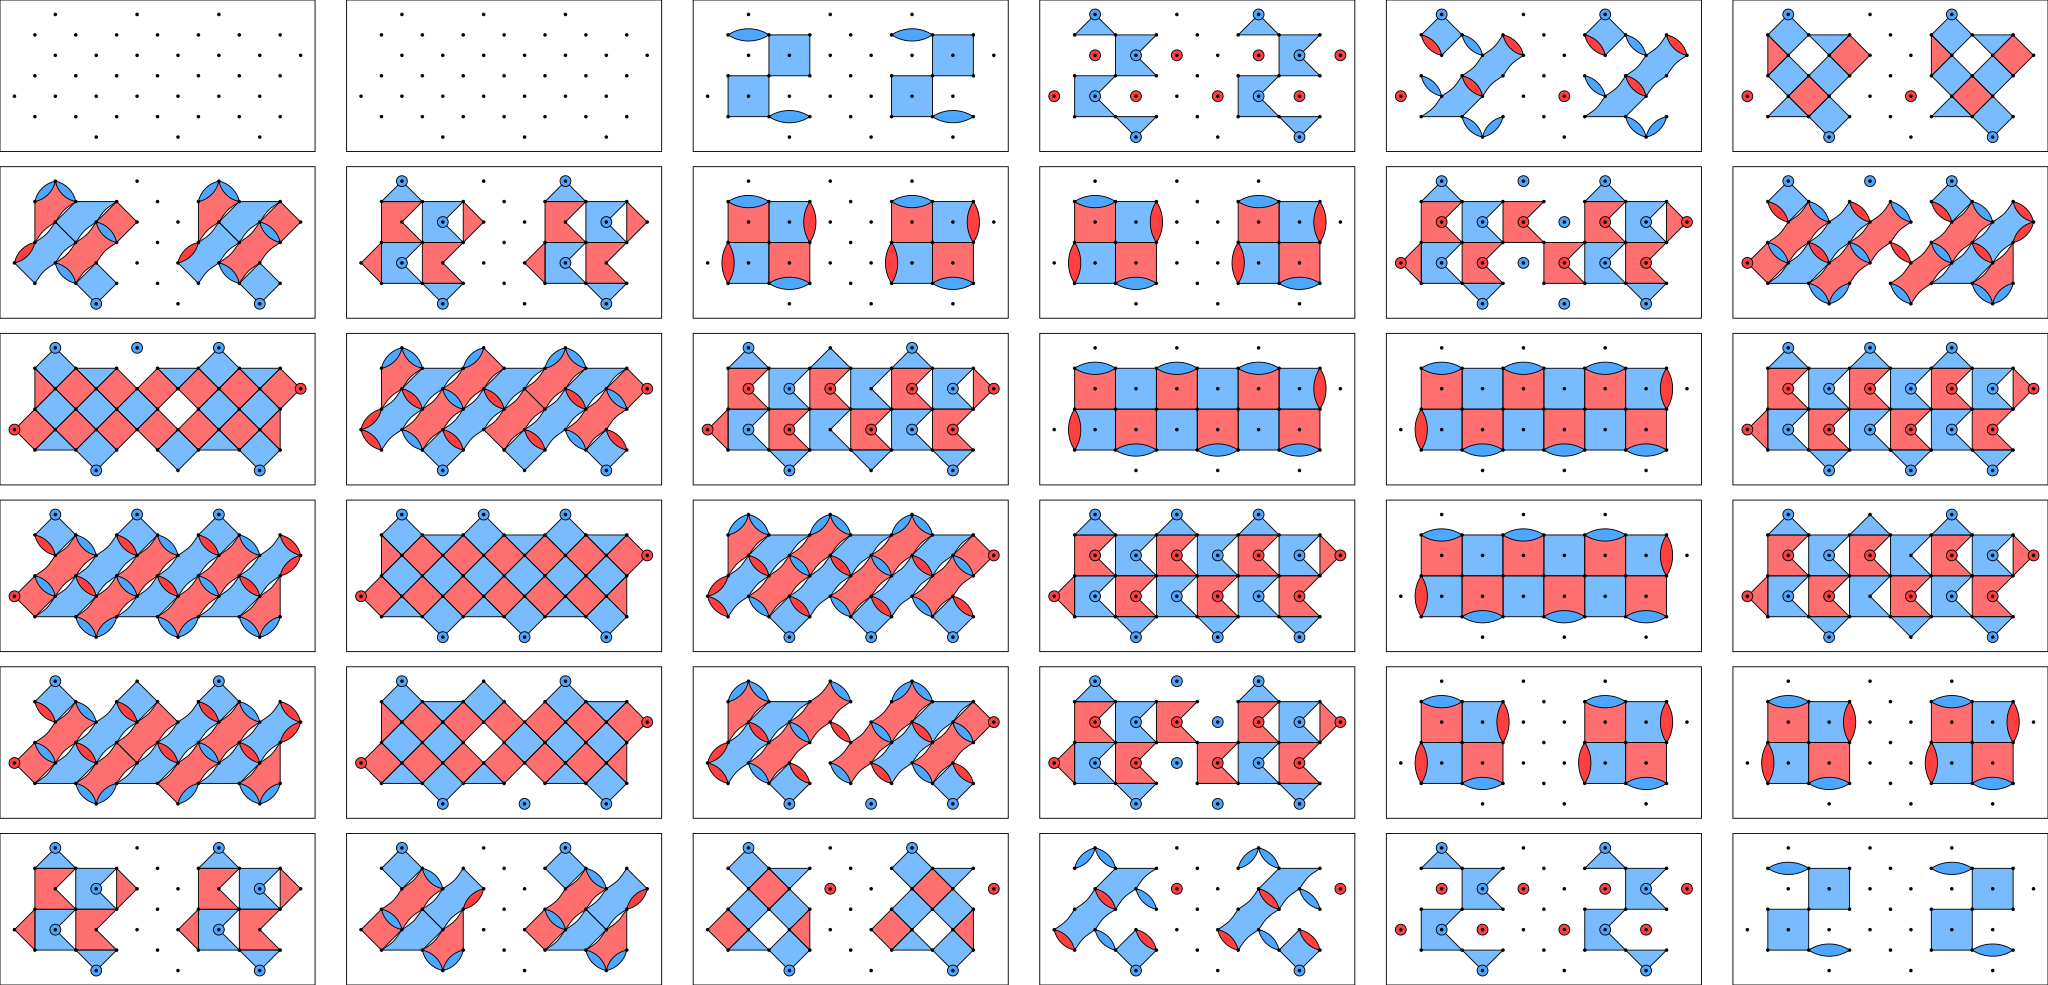

In [ ]:
test_circuit.diagram("detslice-svg")